In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import pickle
import os

print("Imports successful!")

Imports successful!


In [2]:
# Reloading data

col_names = ['unit_id', 'cycle', 'op_sett_1', 'op_sett_2', 'op_sett_3'] + \
            [f'sensor_{i}' for i in range(1, 22)]

train_df = pd.read_csv('../data/raw/train_FD001.txt', sep=r'\s+', header=None, names=col_names)
print(train_df.shape)

(20631, 26)


In [3]:
# Dropping the low-variance sensors identified in EDA
low_variance_sensors = ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16',
                        'sensor_18', 'sensor_19', 'sensor_6', 'sensor_15',
                        'sensor_8', 'sensor_13']

train_df.drop(columns=low_variance_sensors, inplace=True)
print(f"Remaining columns: {train_df.shape[1]}")

Remaining columns: 16


We need RUL in this notebook too since it drives the window labeling later.

In [4]:
max_cycles = train_df.groupby('unit_id')['cycle'].max().reset_index()
max_cycles.columns = ['unit_id', 'max_cycle']
train_df = train_df.merge(max_cycles, on='unit_id')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df.drop(columns=['max_cycle'], inplace=True)
print(train_df.shape)

(20631, 17)


Per-Engine Normalization
We normalize each engine separately so that differences in operating baseline don't get treated as signal.

In [5]:
sensor_cols = [c for c in train_df.columns 
               if c not in ['unit_id', 'cycle', 'op_sett_1', 'op_sett_2', 'op_sett_3', 'RUL']]

scaler_dict = {}
normalized_frames = []

for engine_id, group in train_df.groupby('unit_id'):
    scaler = MinMaxScaler()
    group = group.copy()
    group[sensor_cols] = scaler.fit_transform(group[sensor_cols])
    scaler_dict[engine_id] = scaler
    normalized_frames.append(group)

train_norm = pd.concat(normalized_frames).reset_index(drop=True)
print(f"Normalized shape: {train_norm.shape}")
print(train_norm[sensor_cols].describe().round(3))

Normalized shape: (20631, 17)
        sensor_2   sensor_3   sensor_4   sensor_7   sensor_9  sensor_11  \
count  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000   
mean       0.421      0.435      0.382      0.607      0.393      0.364   
std        0.194      0.194      0.203      0.201      0.242      0.206   
min        0.000      0.000      0.000      0.000      0.000      0.000   
25%        0.284      0.298      0.234      0.491      0.177      0.216   
50%        0.397      0.417      0.345      0.641      0.379      0.317   
75%        0.540      0.552      0.497      0.751      0.577      0.474   
max        1.000      1.000      1.000      1.000      1.000      1.000   

       sensor_12  sensor_14  sensor_17  sensor_20  sensor_21  
count  20631.000  20631.000  20631.000  20631.000  20631.000  
mean       0.623      0.415      0.421      0.591      0.590  
std        0.206      0.260      0.205      0.197      0.198  
min        0.000      0.000      0.000    

We're also saving each engine's scaler in scaler_dict — you'll need those later to inverse-transform predictions.

## Rolling Window Statistics

For RUL regression we want more than raw sensor values — we want *trends*. Rolling mean captures the current level, rolling std captures how erratic the sensor is getting, and rate-of-change captures the direction of drift. We compute all three over 5, 10, and 30-cycle windows for each sensor.

These stats become a flat feature vector (one row per cycle) that we'll slice into per-window snapshots for XGBoost. They are kept separate from `X_windows.npy` so the already-trained LSTM autoencoder is not affected."

In [6]:
roll_windows = [5, 10, 30]
roll_frames = []

for engine_id, group in train_norm.groupby('unit_id'):
    group = group.sort_values('cycle').copy()
    for w in roll_windows:
        for col in sensor_cols:
            group[f'{col}_mean{w}']  = group[col].rolling(w, min_periods=1).mean()
            group[f'{col}_std{w}']   = group[col].rolling(w, min_periods=1).std().fillna(0)
            group[f'{col}_roc{w}']   = group[col].diff(w).fillna(0) / w
    roll_frames.append(group)

train_rolled = pd.concat(roll_frames).reset_index(drop=True)

roll_feature_cols = [c for c in train_rolled.columns
                     if any(f'_mean{w}' in c or f'_std{w}' in c or f'_roc{w}' in c
                            for w in roll_windows)]

print(f"Rolling features added: {len(roll_feature_cols)}")
print(f"  ({len(sensor_cols)} sensors × 3 stats × 3 windows = {len(sensor_cols)*3*3})")
print(f"Total columns in train_rolled: {train_rolled.shape[1]}")
train_rolled[roll_feature_cols[:6]].head()

/var/folders/bn/pm60wxsd46l_vxj_rw7xtpzm0000gn/T/ipykernel_7401/3279148648.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  group[f'{col}_roc{w}']   = group[col].diff(w).fillna(0) / w


Rolling features added: 99
  (11 sensors × 3 stats × 3 windows = 99)
Total columns in train_rolled: 116


,sensor_2_mean5,sensor_2_std5,sensor_2_roc5,sensor_3_mean5,sensor_3_std5,sensor_3_roc5
0,0.044000,0.000000,0.0,0.434626,0.000000,0.0
1,0.110000,0.093338,0.0,0.472701,0.053846,0.0
2,0.158667,0.107058,0.0,0.439535,0.068917,0.0
3,0.183000,0.100047,0.0,0.376257,0.138502,0.0
4,0.199200,0.093911,0.0,0.338721,0.146396,0.0


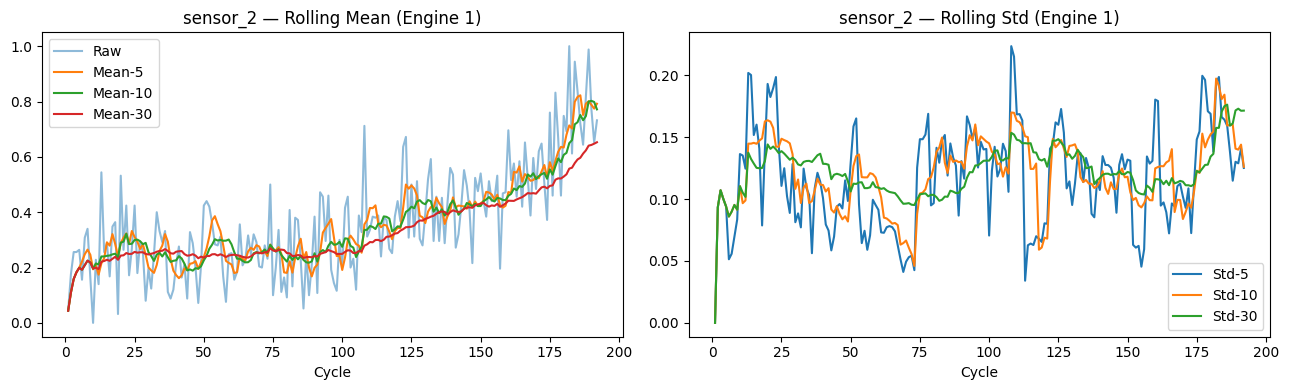

In [7]:
import matplotlib.pyplot as plt

# Visualise rolling mean vs raw for one sensor on one engine
eng1 = train_rolled[train_rolled['unit_id'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(eng1['cycle'], eng1['sensor_2'],        alpha=0.5, label='Raw')
ax.plot(eng1['cycle'], eng1['sensor_2_mean5'],  label='Mean-5')
ax.plot(eng1['cycle'], eng1['sensor_2_mean10'], label='Mean-10')
ax.plot(eng1['cycle'], eng1['sensor_2_mean30'], label='Mean-30')
ax.set_title('sensor_2 — Rolling Mean (Engine 1)')
ax.set_xlabel('Cycle')
ax.legend()

ax = axes[1]
ax.plot(eng1['cycle'], eng1['sensor_2_std5'],  label='Std-5')
ax.plot(eng1['cycle'], eng1['sensor_2_std10'], label='Std-10')
ax.plot(eng1['cycle'], eng1['sensor_2_std30'], label='Std-30')
ax.set_title('sensor_2 — Rolling Std (Engine 1)')
ax.set_xlabel('Cycle')
ax.legend()

plt.tight_layout()
plt.savefig('../results/rolling_stats_example.png', dpi=150)
plt.show()

In [8]:
# Build flat feature matrix for RUL regression
# One row = last cycle of a 30-cycle window, containing raw + rolling stats
window_size       = 30
failure_threshold = 30
all_feature_cols  = sensor_cols + roll_feature_cols

X_feat_list, y_rul_list, y_label_list, eid_list = [], [], [], []

for engine_id, group in train_rolled.groupby('unit_id'):
    group = group.sort_values('cycle').reset_index(drop=True)
    vals  = group[all_feature_cols].values
    rul_v = group['RUL'].values

    for i in range(window_size - 1, len(group)):
        X_feat_list.append(vals[i])
        y_rul_list.append(rul_v[i])
        y_label_list.append(1 if rul_v[i] < failure_threshold else 0)
        eid_list.append(engine_id)

X_features      = np.array(X_feat_list)
y_rul           = np.array(y_rul_list)
y_labels_flat   = np.array(y_label_list)
engine_ids_flat = np.array(eid_list)

print(f"X_features shape: {X_features.shape}")
print(f"  {len(all_feature_cols)} features = {len(sensor_cols)} raw + {len(roll_feature_cols)} rolling")
print(f"y_rul shape: {y_rul.shape}  |  min: {y_rul.min()}  max: {y_rul.max()}")

X_features shape: (17731, 110)
  110 features = 11 raw + 99 rolling
y_rul shape: (17731,)  |  min: 0  max: 332


In [9]:
np.save('../data/processed/X_features.npy',      X_features)
np.save('../data/processed/y_rul.npy',           y_rul)
np.save('../data/processed/y_labels_flat.npy',   y_labels_flat)
np.save('../data/processed/engine_ids_flat.npy', engine_ids_flat)

import pickle
with open('../data/processed/feature_cols.pkl', 'wb') as f:
    pickle.dump(all_feature_cols, f)

print("Saved:")
print(f"  X_features.npy      {X_features.shape}")
print(f"  y_rul.npy           {y_rul.shape}")
print(f"  y_labels_flat.npy   {y_labels_flat.shape}")
print(f"  engine_ids_flat.npy {engine_ids_flat.shape}")
print(f"  feature_cols.pkl    ({len(all_feature_cols)} feature names)")

Saved:
  X_features.npy      (17731, 110)
  y_rul.npy           (17731,)
  y_labels_flat.npy   (17731,)
  engine_ids_flat.npy (17731,)
  feature_cols.pkl    (110 feature names)


Building rolling windows for the LSTM autoencoder.

In [10]:
window_size = 30
failure_threshold = 30

feature_cols = sensor_cols

def create_sequences(df, window_size):
    sequences = []
    labels = []
    unit_ids = []
    rul_targets = []
    
    for engine_id, group in df.groupby('unit_id'):
        group = group.sort_values('cycle').reset_index(drop=True)
        values = group[feature_cols].values
        rul = group['RUL'].values
        
        for i in range(len(group) - window_size + 1):
            seq = values[i:i+window_size]
            seq_rul = rul[i+window_size-1]
            label = 1 if seq_rul < failure_threshold else 0
            sequences.append(seq)
            labels.append(label)
            unit_ids.append(engine_id)
            rul_targets.append(seq_rul)
            
    return np.array(sequences), np.array(labels), np.array(unit_ids), np.array(rul_targets)

X, y, engine_ids, rul_targets = create_sequences(train_norm, window_size)

print(X.shape, y.shape)
print("Anomaly rate:", y.mean().round(4))

(17731, 30, 11) (17731,)
Anomaly rate: 0.1692


Each window becomes one training example, and the label marks whether the engine was already in the failure zone at the end of that window. That gives you the supervised target for evaluating anomaly detection later, even though the autoencoder itself will still train on normal behavior.

In [11]:
# Saving processed arrays so the modeling notebook can load them directly
os.makedirs('../data/processed', exist_ok=True)

np.save('../data/processed/X_windows.npy', X)
np.save('../data/processed/y_labels.npy', y)
np.save('../data/processed/engine_ids.npy', engine_ids)
np.save('../data/processed/rul_targets.npy', rul_targets)

with open('../data/processed/scaler_dict.pkl', 'wb') as f:
    pickle.dump(scaler_dict, f)

print("Saved processed files!")

Saved processed files!


In [12]:
#Personal sanity check
print("X sample shape:", X[0].shape)
print("First label:", y[0])
print("First RUL target:", rul_targets[0])

X sample shape: (30, 11)
First label: 0
First RUL target: 162


In [13]:
print("Total windows:", len(X))
print("Normal windows:", (y == 0).sum())
print("Anomalous windows:", (y == 1).sum())
print("Feature dimensions:", X.shape[1], "timesteps by", X.shape[2], "features")

Total windows: 17731
Normal windows: 14731
Anomalous windows: 3000
Feature dimensions: 30 timesteps by 11 features
